<a href="https://colab.research.google.com/github/ArshanBhanage/Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/Part2_TF_Advanced_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ Part 2 · TensorFlow Advanced Training Techniques
**Topics:**  
Custom Learning Rate Scheduler · Custom Optimizer · Custom Training Loop · TensorBoard

> **Dataset:** CIFAR-10  
> **Framework:** TensorFlow / Keras  
> **Goal:** Go beyond `model.fit()` — control every step of the training pipeline.


In [1]:
!pip install -q tensorflow tensorboard matplotlib pandas


In [2]:
import os, random, datetime
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__)


TF: 2.19.0


## 1 · Data Loading — CIFAR-10

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test .astype("float32")/255.0
y_train = y_train.squeeze(); y_test = y_test.squeeze()

x_tr, y_tr   = x_train[:8000], y_train[:8000]
x_val, y_val = x_train[8000:10000], y_train[8000:10000]

train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(8000,seed=SEED).batch(64).prefetch(2)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val,y_val)).batch(256).prefetch(2)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


## 2 · Custom Learning Rate Scheduler — Cosine Annealing with Warm Restart

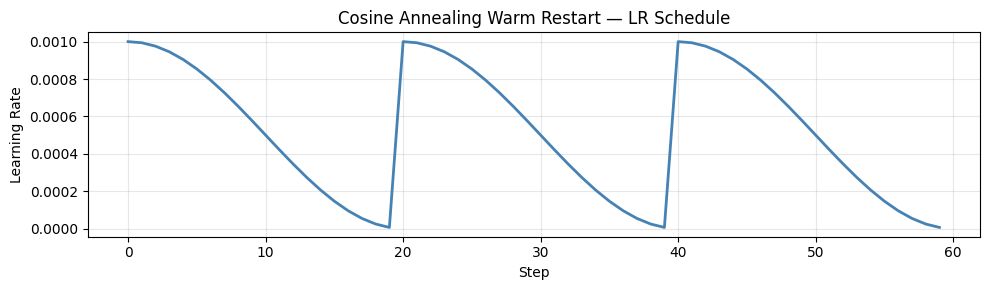

In [4]:
class CosineAnnealingWarmRestart(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    SGDR — Stochastic Gradient Descent with Warm Restarts (Loshchilov & Hutter 2017).
    lr(t) = lr_min + 0.5*(lr_max - lr_min) * (1 + cos(pi * t_cur / T_i))
    At each restart T_i multiplies by t_mult.
    """
    def __init__(self, lr_max=1e-3, lr_min=1e-6, T0=10, t_mult=2):
        super().__init__()
        self.lr_max  = lr_max
        self.lr_min  = lr_min
        self.T0      = T0
        self.t_mult  = t_mult

    def __call__(self, step):
        step  = tf.cast(step, tf.float32)
        T0    = tf.cast(self.T0, tf.float32)
        t_mult= tf.cast(self.t_mult, tf.float32)

        # Find current cycle and position within it
        # Simplified: restart every T0 steps (no exponential growth for simplicity)
        t_cur = tf.math.mod(step, T0)
        cos_out = tf.math.cos(np.pi * t_cur / T0)
        return self.lr_min + 0.5*(self.lr_max - self.lr_min)*(1.0 + cos_out)

    def get_config(self):
        return {"lr_max": self.lr_max, "lr_min": self.lr_min,
                "T0": self.T0, "t_mult": self.t_mult}

# Visualise the schedule
sched = CosineAnnealingWarmRestart(lr_max=1e-3, lr_min=1e-6, T0=20)
lr_vals = [sched(i).numpy() for i in range(60)]
plt.figure(figsize=(10,3))
plt.plot(lr_vals, color="steelblue", linewidth=2)
plt.title("Cosine Annealing Warm Restart — LR Schedule")
plt.xlabel("Step"); plt.ylabel("Learning Rate"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3 · Custom Optimizer — SGD with Gradient Clipping & Momentum

In [5]:
class ClippedMomentumSGD(tf.keras.optimizers.Optimizer):
    """
    SGD + Momentum + hard gradient clipping.
    Shows the Keras Optimizer API; functionally equivalent to
    tf.keras.optimizers.SGD(clipnorm=...) but fully transparent.
    """
    def __init__(self, learning_rate=0.01, momentum=0.9, clip_norm=1.0, **kwargs):
        super().__init__(name="ClippedMomentumSGD", **kwargs)
        self._lr       = learning_rate
        self.momentum  = momentum
        self.clip_norm = clip_norm

    @property
    def learning_rate(self):
        return self._lr

    def build(self, var_list):
        super().build(var_list)
        # Velocity buffers
        self._velocities = [self.add_variable_from_reference(
                                model_variable=v, variable_name="velocity")
                            for v in var_list]

    def update_step(self, gradient, variable):
        # Clip gradient
        gradient, _ = tf.clip_by_global_norm([gradient], self.clip_norm)
        gradient = gradient[0]
        idx = self._get_variable_index(variable)
        v   = self._velocities[idx]
        # v = momentum*v + gradient
        v.assign(self.momentum * v + gradient)
        variable.assign_sub(self._lr * v)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"learning_rate": self._lr, "momentum": self.momentum,
                    "clip_norm": self.clip_norm})
        return cfg

print("Custom optimizer defined successfully.")


Custom optimizer defined successfully.


## 4 · Model Definition

In [6]:
def build_small_cnn():
    inp = tf.keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inp, out)


## 5 · Custom Training Loop with GradientTape

TF: 2.19.0


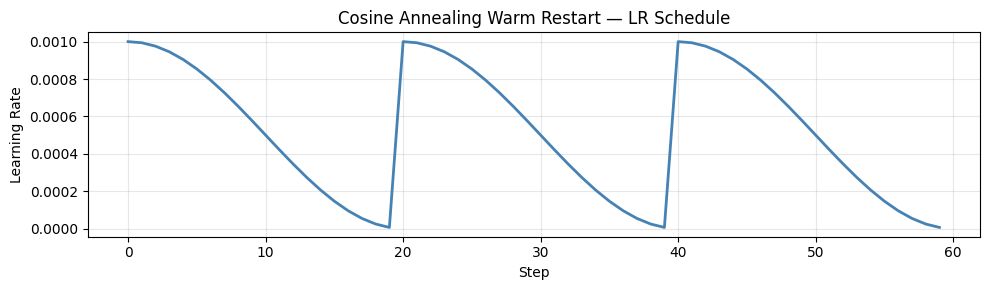

Custom optimizer defined successfully.
Epoch  1/12  train_loss=1.9264 train_acc=0.3290  val_loss=2.6510 val_acc=0.1595
Epoch  2/12  train_loss=1.5355 train_acc=0.4539  val_loss=2.7936 val_acc=0.1710
Epoch  3/12  train_loss=1.3556 train_acc=0.5210  val_loss=2.2866 val_acc=0.2585
Epoch  4/12  train_loss=1.2034 train_acc=0.5745  val_loss=1.5302 val_acc=0.4640
Epoch  5/12  train_loss=1.0944 train_acc=0.6111  val_loss=1.3241 val_acc=0.5300
Epoch  6/12  train_loss=0.9744 train_acc=0.6633  val_loss=1.2488 val_acc=0.5520
Epoch  7/12  train_loss=0.8675 train_acc=0.6906  val_loss=1.2120 val_acc=0.5700
Epoch  8/12  train_loss=0.7913 train_acc=0.7245  val_loss=1.2067 val_acc=0.5685
Epoch  9/12  train_loss=0.7177 train_acc=0.7511  val_loss=1.1866 val_acc=0.5850
Epoch 10/12  train_loss=0.6306 train_acc=0.7883  val_loss=1.1964 val_acc=0.5845
Epoch 11/12  train_loss=0.5678 train_acc=0.8112  val_loss=1.1769 val_acc=0.5825
Epoch 12/12  train_loss=0.5018 train_acc=0.8350  val_loss=1.1793 val_acc=0.5925



In [8]:
import os, random, datetime
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TF:", tf.__version__)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
y_train = y_train.squeeze()
y_test = y_test.squeeze()

x_tr, y_tr = x_train[:8000], y_train[:8000]
x_val, y_val = x_train[8000:10000], y_train[8000:10000]

train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(8000, seed=SEED).batch(64).prefetch(2)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(256).prefetch(2)

class CosineAnnealingWarmRestart(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    SGDR — Stochastic Gradient Descent with Warm Restarts (Loshchilov & Hutter 2017).
    lr(t) = lr_min + 0.5*(lr_max - lr_min) * (1 + cos(pi * t_cur / T_i))
    At each restart T_i multiplies by t_mult.
    """
    def __init__(self, lr_max=1e-3, lr_min=1e-6, T0=10, t_mult=2):
        super().__init__()
        self.lr_max = lr_max
        self.lr_min = lr_min
        self.T0 = T0
        self.t_mult = t_mult

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        T0 = tf.cast(self.T0, tf.float32)
        t_mult = tf.cast(self.t_mult, tf.float32)

        # Find current cycle and position within it
        # Simplified: restart every T0 steps (no exponential growth for simplicity)
        t_cur = tf.math.mod(step, T0)
        cos_out = tf.math.cos(np.pi * t_cur / T0)
        return self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1.0 + cos_out)

    def get_config(self):
        return {"lr_max": self.lr_max, "lr_min": self.lr_min,
                "T0": self.T0, "t_mult": self.t_mult}

# Visualise the schedule
sched = CosineAnnealingWarmRestart(lr_max=1e-3, lr_min=1e-6, T0=20)
lr_vals = [sched(i).numpy() for i in range(60)]
plt.figure(figsize=(10,3))
plt.plot(lr_vals, color="steelblue", linewidth=2)
plt.title("Cosine Annealing Warm Restart — LR Schedule")
plt.xlabel("Step"); plt.ylabel("Learning Rate"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

class ClippedMomentumSGD(tf.keras.optimizers.Optimizer):
    """
    SGD + Momentum + hard gradient clipping.
    Shows the Keras Optimizer API; functionally equivalent to
    tf.keras.optimizers.SGD(clipnorm=...) but fully transparent.
    """
    def __init__(self, learning_rate=0.01, momentum=0.9, clip_norm=1.0, **kwargs):
        super().__init__(name="ClippedMomentumSGD", **kwargs)
        self._lr = learning_rate
        self.momentum = momentum
        self.clip_norm = clip_norm

    @property
    def learning_rate(self):
        return self._lr

    def build(self, var_list):
        super().build(var_list)
        # Velocity buffers
        self._velocities = [self.add_variable_from_reference(
                                model_variable=v, variable_name="velocity")
                            for v in var_list]

    def update_step(self, gradient, variable):
        # Clip gradient
        gradient, _ = tf.clip_by_global_norm([gradient], self.clip_norm)
        gradient = gradient[0]
        idx = self._get_variable_index(variable)
        v = self._velocities[idx]
        # v = momentum*v + gradient
        v.assign(self.momentum * v + gradient)
        variable.assign_sub(self._lr * v)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"learning_rate": self._lr, "momentum": self.momentum,
                    "clip_norm": self.clip_norm})
        return cfg

print("Custom optimizer defined successfully.")

def build_small_cnn():
    inp = tf.keras.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(10, activation="softmax")(x)
    return tf.keras.Model(inp, out)

# Loss and metric objects
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()

# Cosine annealing schedule
sched = CosineAnnealingWarmRestart(lr_max=3e-4, lr_min=1e-6, T0=125)
optimizer = tf.keras.optimizers.Adam(learning_rate=sched)

# TensorBoard writer
LOG_DIR = "/tmp/tb_custom_loop/" + datetime.datetime.now().strftime("%H%M%S")
writer = tf.summary.create_file_writer(LOG_DIR)

model = build_small_cnn()

EPOCHS = 12
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
global_step = tf.Variable(0, trainable=False, dtype=tf.int64)

for epoch in range(EPOCHS):
    # ── Training phase ─────────────────────────────────────
    train_acc_metric.reset_state()
    epoch_loss = 0.0
    n_batches = 0
    for xb, yb in train_ds:
        with tf.GradientTape() as tape:
            preds = model(xb, training=True)
            loss = loss_fn(yb, preds)
        grads = tape.gradient(loss, model.trainable_variables)
        # Gradient clipping (manual)
        grads, gnorm = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_acc_metric.update_state(yb, preds)
        epoch_loss += loss.numpy()
        n_batches += 1
        global_step.assign_add(1)

        # Log to TensorBoard every 50 steps
        if global_step % 50 == 0:
            with writer.as_default():
                tf.summary.scalar("step/loss", loss, step=global_step)
                tf.summary.scalar("step/lr",
                    sched(global_step), step=global_step)

    train_loss = epoch_loss / n_batches
    train_acc = train_acc_metric.result().numpy()

    # ── Validation phase ──────────────────────────────────
    val_acc_metric.reset_state()
    val_loss = 0.0
    vn = 0
    for xb, yb in val_ds:
        preds = model(xb, training=False)
        val_loss += loss_fn(yb, preds).numpy()
        vn += 1
        val_acc_metric.update_state(yb, preds)
    val_loss /= vn
    val_acc = val_acc_metric.result().numpy()

    # Log epoch-level metrics
    with writer.as_default():
        tf.summary.scalar("epoch/train_acc", train_acc, step=epoch)
        tf.summary.scalar("epoch/val_acc", val_acc, step=epoch)
        tf.summary.scalar("epoch/train_loss", train_loss, step=epoch)
        tf.summary.scalar("epoch/val_loss", val_loss, step=epoch)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f}  "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

writer.flush()
print("\nTensorBoard logs:", LOG_DIR)
print("# In Colab run:")
print("# %load_ext tensorboard")
print("# %tensorboard --logdir /tmp/tb_custom_loop")


## 6 · Compare Custom Loop vs model.fit()

In [9]:
# Standard model.fit() with same architecture for comparison
m_fit = build_small_cnn()
m_fit.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
hist_fit = m_fit.fit(x_tr, y_tr, epochs=EPOCHS, batch_size=64,
                     validation_data=(x_val,y_val), verbose=0)

# Evaluate both
_, acc_fit    = m_fit.evaluate(x_test, y_test, verbose=0)
preds_custom  = model(x_test.astype("float32"), training=False)
acc_custom    = float(tf.keras.metrics.sparse_categorical_accuracy(
                    y_test, preds_custom).numpy().mean())

df = pd.DataFrame([
    {"Training Method": "model.fit() (built-in)",   "Test Acc": round(acc_fit, 4),
     "Control over Grads": "Low", "TensorBoard": "Via callback"},
    {"Training Method": "Custom GradientTape loop", "Test Acc": round(acc_custom,4),
     "Control over Grads": "Full", "TensorBoard": "Manual tf.summary"},
])
print(df.to_string(index=False))


         Training Method  Test Acc Control over Grads       TensorBoard
  model.fit() (built-in)    0.5312                Low      Via callback
Custom GradientTape loop    0.5918               Full Manual tf.summary


## 7 · Learning Curves

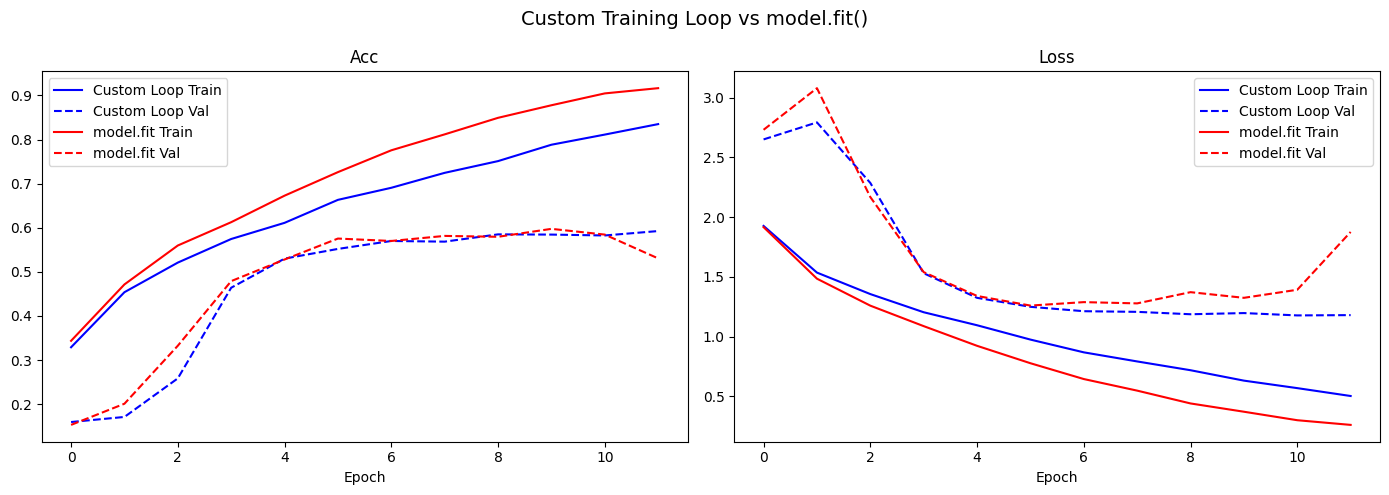

In [10]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
for metric, ax in zip(["acc","loss"], axes):
    ax.plot(history[f"train_{metric}"], "b-",  label="Custom Loop Train")
    ax.plot(history[f"val_{metric}"],   "b--", label="Custom Loop Val")
    if metric == "acc":
        ax.plot(hist_fit.history["accuracy"],     "r-",  label="model.fit Train")
        ax.plot(hist_fit.history["val_accuracy"], "r--", label="model.fit Val")
    else:
        ax.plot(hist_fit.history["loss"],     "r-",  label="model.fit Train")
        ax.plot(hist_fit.history["val_loss"], "r--", label="model.fit Val")
    ax.set_title(metric.capitalize()); ax.legend(); ax.set_xlabel("Epoch")
plt.suptitle("Custom Training Loop vs model.fit()", fontsize=14)
plt.tight_layout(); plt.show()


## 8 · Conclusion

| Aspect | model.fit() | Custom GradientTape |
|---|---|---|
| **Ease of use** | ✅ Simple | ❌ Verbose |
| **Gradient control** | ❌ Automatic | ✅ Full access |
| **Custom schedules** | Via callback | ✅ Inline |
| **Research flexibility** | Limited | ✅ Unlimited |
| **TensorBoard** | Via callback | ✅ Manual `tf.summary` |
| **Multi-task loss** | Difficult | ✅ Native |

> Use `model.fit()` for standard pipelines.  
> Switch to `GradientTape` when you need per-step gradient inspection,
> custom multi-task losses, or meta-learning algorithms.
